In [1]:
from importlib import reload
import FuncGarchEstimators as est # Estimator
import FuncGarchSimulators as sim # Simulator
import pandas as pd
import numpy as np

from numba import jit, njit

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (24, 8)

FuncGarchEstimators V.1.0.5


In [2]:
# This is minute interval price data for BTC
prices = pd.read_csv('price_data_example.csv', parse_dates = True, index_col = 'date')
prices = prices[(prices.index >= '2023-12-14') & (prices.index <= '2024-02-22')]
prices['BTCUSDT'] = prices.mean(axis = 1)
prices = prices[['BTCUSDT']]

In [3]:
returns = prices[1:] / prices[:-1].values - 1
mY_real = np.zeros((int(returns.__len__() / 70), 70))
for k in range(70):
    n = k * 1440
    N = n + 1440
    mY_real[:, k] = returns.iloc[n:N].T.values

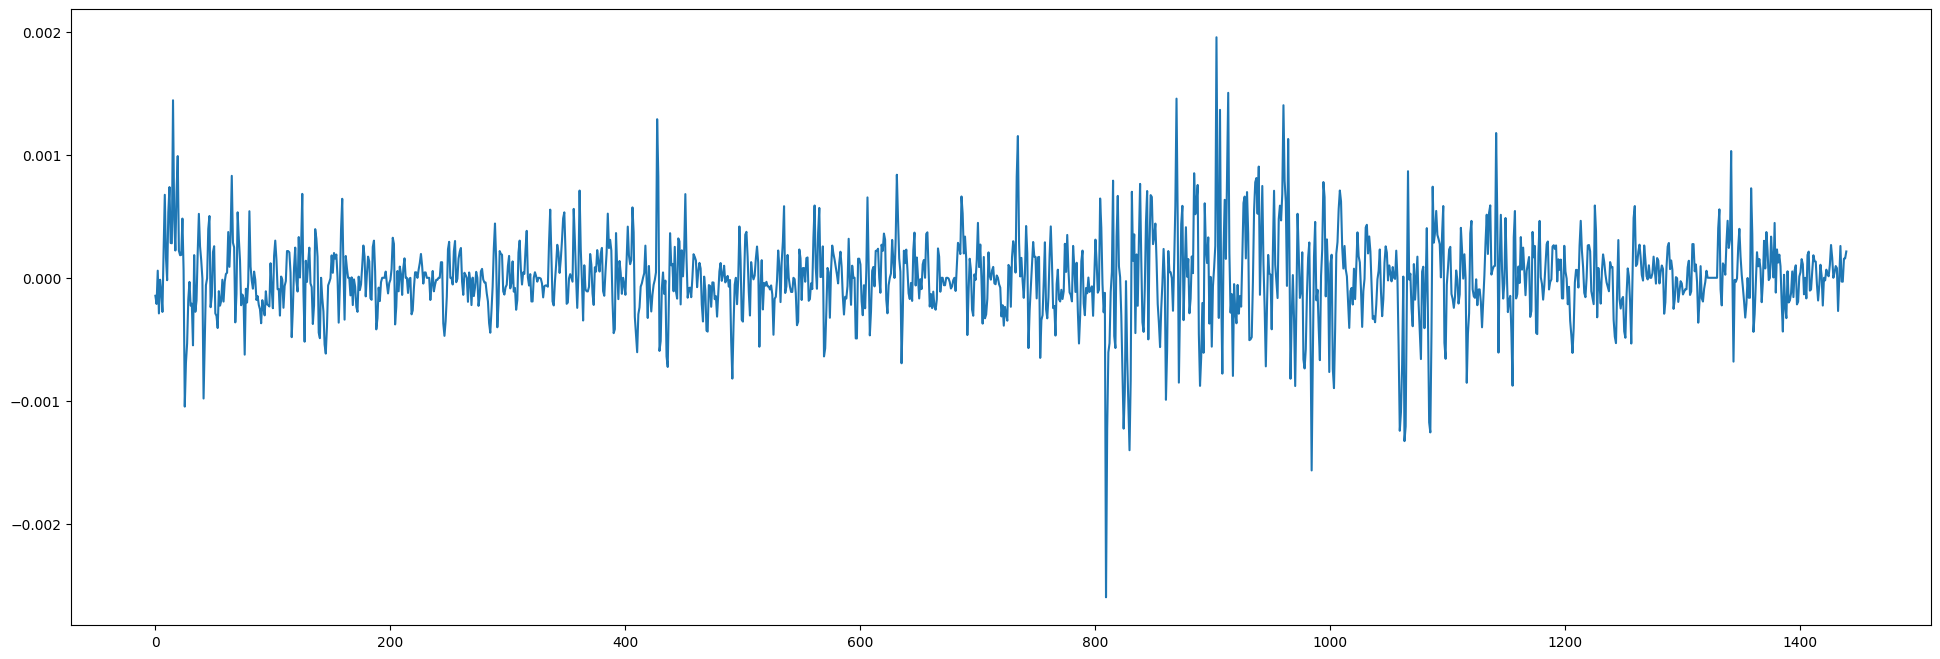

In [4]:
plt.plot(mY_real[:, 50])

In [5]:
# Our first example, which is data generated by functions from the space of Bernstein polynomials
M = 3
coefs_delta: list = [.0, 1.0, 5.0]
coefs_alpha: list = [.0, .0, 1.0] * M
coefs_beta : list = [.0, .0, .6] * M

coefs: dict = {'coefs_delta':coefs_delta,'coefs_alpha':coefs_alpha,'coefs_beta':coefs_beta, 'M':M}

mY_example1, mSigma_example1 = sim.simulate(SamLen = 250, PSamLen = 0, GridLegth = 285, **coefs)

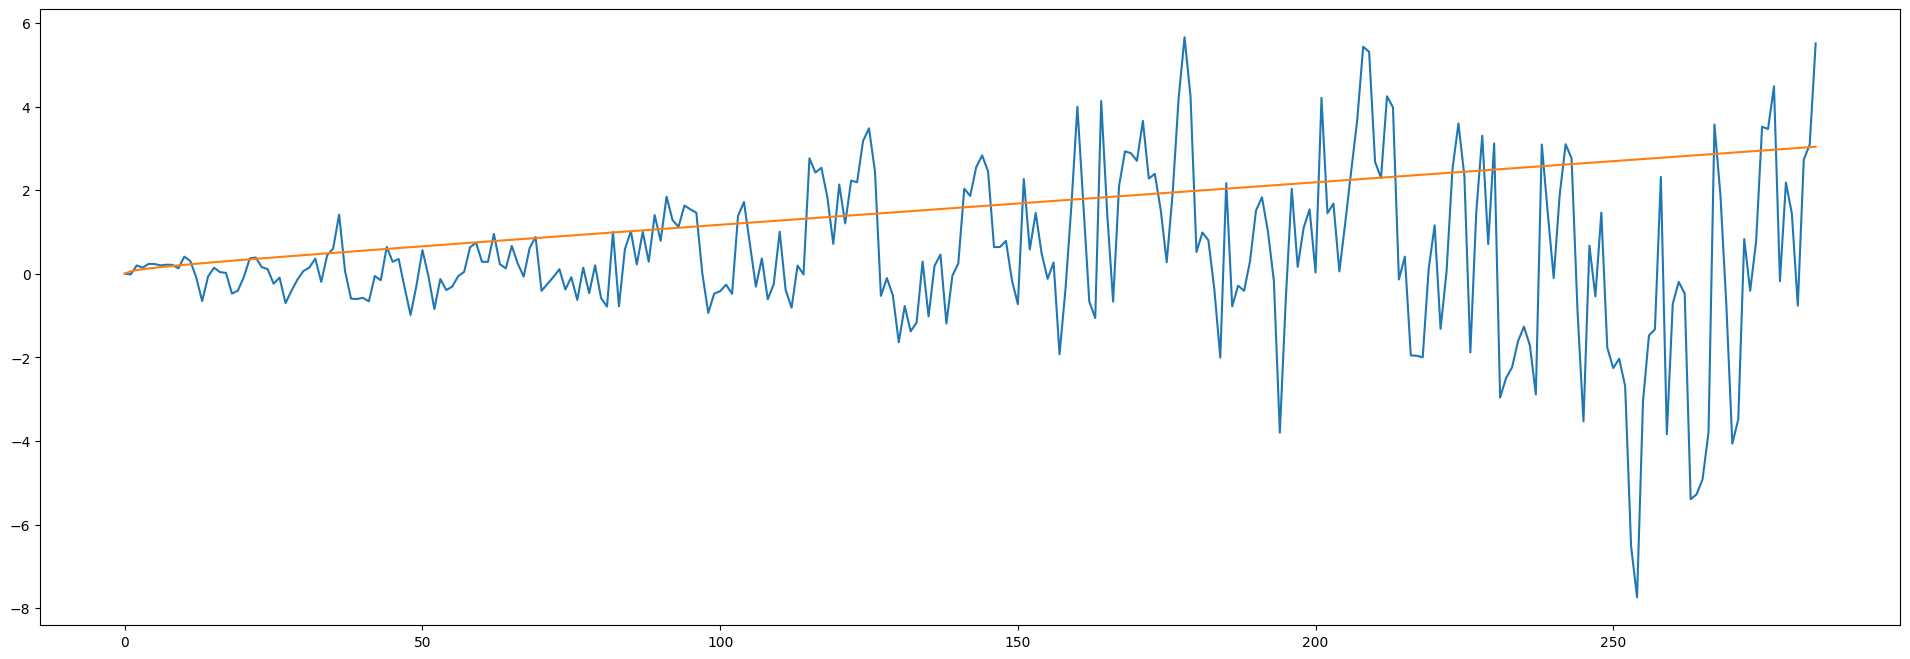

In [6]:
plt.plot(mY_example1[:, 50])
plt.plot(np.sqrt(mSigma_example1[:, 50]))

Let us create our own functional operators (this is the example from Aeu et al.).

We leave the parameters of the functions as these are needed for the models stored in FuncGarchEstimators.

In [7]:
@njit
def delta(coefs: list, t: float, M: int) -> ...:
    """
    Delta operator for fixed (t,s) on R x R
    NOTE: ...
    """
    return (t - .5) ** 2 + .1

@jit(nopython = True)
def operator(t: float, s: est.typing.Any, M: int, k: int, l: int):
    return (s - .5) ** 2 + (t - .5) ** 2 + .2

@jit(nopython = True)
def functional_operator(t: est.typing.Any, s: est.typing.Any, coefs: float, M: int = 1):
    _final = np.zeros(s.shape)
    _final = _final + coefs * operator(t = t, s = s, M = M, k = 0, l = 0)
    return _final


In [8]:
# This is example 2 in Cerovecki on p. 363
M = 1
coefs_delta: list = [.0]
coefs_alpha: list = 1
coefs_beta : list = 1

coefs: dict = {'coefs_delta':coefs_delta,'coefs_alpha':coefs_alpha,'coefs_beta':coefs_beta}

mY_example2, mSigma_example2 = sim.simulate(SamLen = 250, PSamLen = 0, GridLegth = 285, delta = delta, functional_operator = functional_operator, **coefs)

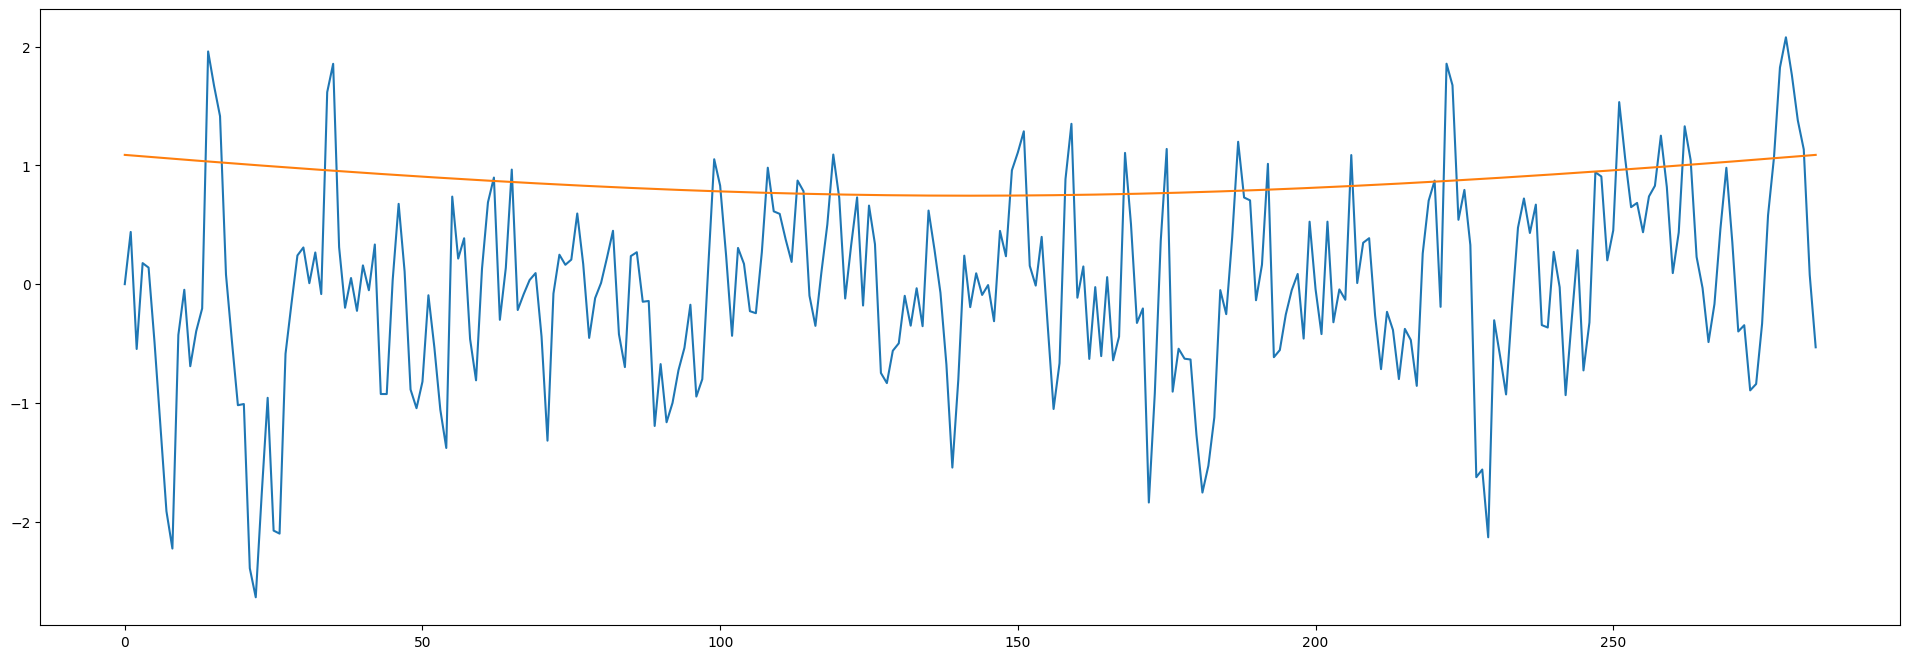

In [9]:
plt.plot(mY_example2[:, 50])
plt.plot(np.sqrt(mSigma_example2[:, 50]))

In [10]:
M: int = 2
config: dict = {
        'x0'        :   [.5] * (M + 2 * (M ** 2)),
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead', 
    }

# This estimation is done using the Bernstein polynomials
vtheta_hat_example2 = est.main(mY_example2, grid_length = 285, M = M, sigma2Int=np.ones(285), **config)

In [19]:
vtheta_hat_example2.x

array([ 0.40503599, -0.04983099,  0.28931124,  0.78389999,  0.96681098,
        0.56957728, -0.35856931,  1.09118313, -0.00802227, -0.2210256 ])

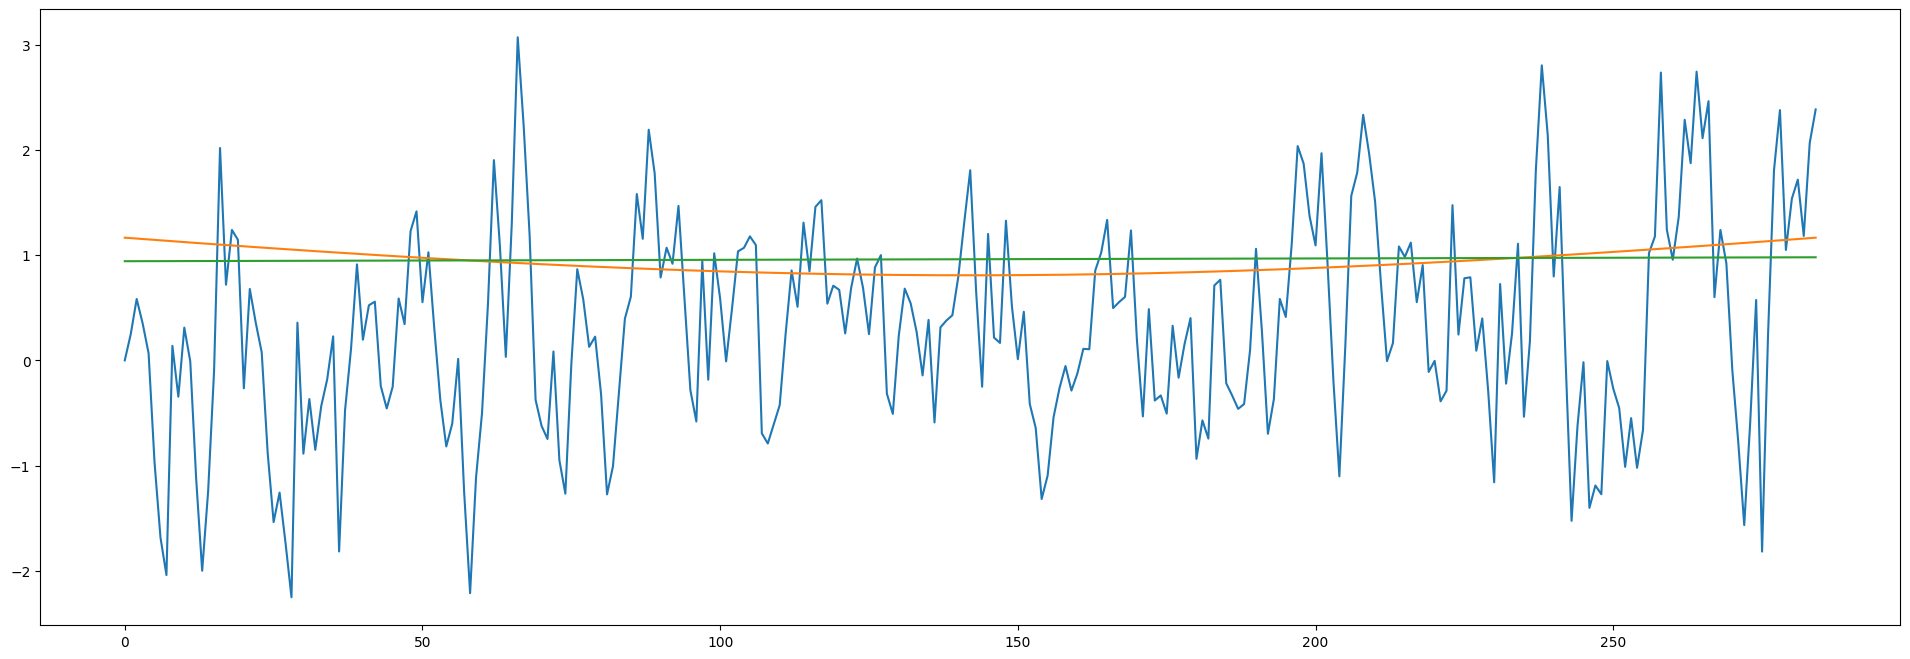

In [28]:
coefs_example2 = vtheta_hat_example2.x
mSigma_hat_example2 = sim.CUDAfilter(mY_example2, 285, coefs_example2, M, np.ones(285))

plt.plot(mY_example2[:, 100])
plt.plot(np.sqrt(mSigma_example2[:, 100]))
plt.plot(np.sqrt(mSigma_hat_example2[:, 100]))

For estimation, we consider the following basis

In [29]:
@jit(nopython = True)
def basis_operator(t: float, M: int, k: int, l: int):
    if k == 1: return 0 * t + 1 # This is needed as t can either be a list or a float, so taking the shape operaror yields errors
    if k == 2: return (t ** 2 - .5)
    if k == 3: return (t ** 2 - t + 5/6)

@njit
def basis_f(t, s, coefs: list, M: int):
    _final = np.zeros(s.shape)
    indexer: int = 0
    for k in range(1, M + 1):
        for l in range(1, M + 1):
            coef = coefs[indexer]
            _final = _final + coef * basis_operator(t = t, M = M, k = k, l = l) * basis_operator(t = s, M = M, k = l, l = l)
            indexer = indexer + 1
    return _final

@njit
def basis_g(coefs: list, t, M: int):

    _final = 0 * t
    indexer: int = 0
    for k in range(1, M + 1):
        coef = coefs[indexer]
        _final = _final + coef * basis_operator(t = t, M = M, k = k, l = 0)
        indexer = indexer + 1
    return _final

In [30]:
M: int = 3
config: dict = {
        'x0'        :   [.5] * (M + 2 * (M ** 2)),
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead', # Sequential least squares programming,
    }

QMLE_example_basis2 = est.main(mY_example2, grid_length = 285, M = M, sigma2Int=np.ones(285), delta = basis_g, functional_operator = basis_f, **config)

In [31]:
QMLE_example_basis2.x

array([-0.20966469, -0.5470212 ,  0.41227753,  1.05492888,  0.68506709,
       -0.90268272, -0.33693201, -0.75954786,  0.59686921, -0.21094612,
       -0.80779389,  0.85228742, -3.12852148, -0.5473187 ,  2.6643041 ,
        0.06484464,  2.65395084,  1.3029203 ,  0.68238824,  0.61563963,
        2.39936246])

In [32]:
coefs_example2_db = QMLE_example_basis2.x
mSigma_hat_example2_db = sim.CUDAfilter(mY_example2, 285, coefs_example2_db, 3, np.ones(285))

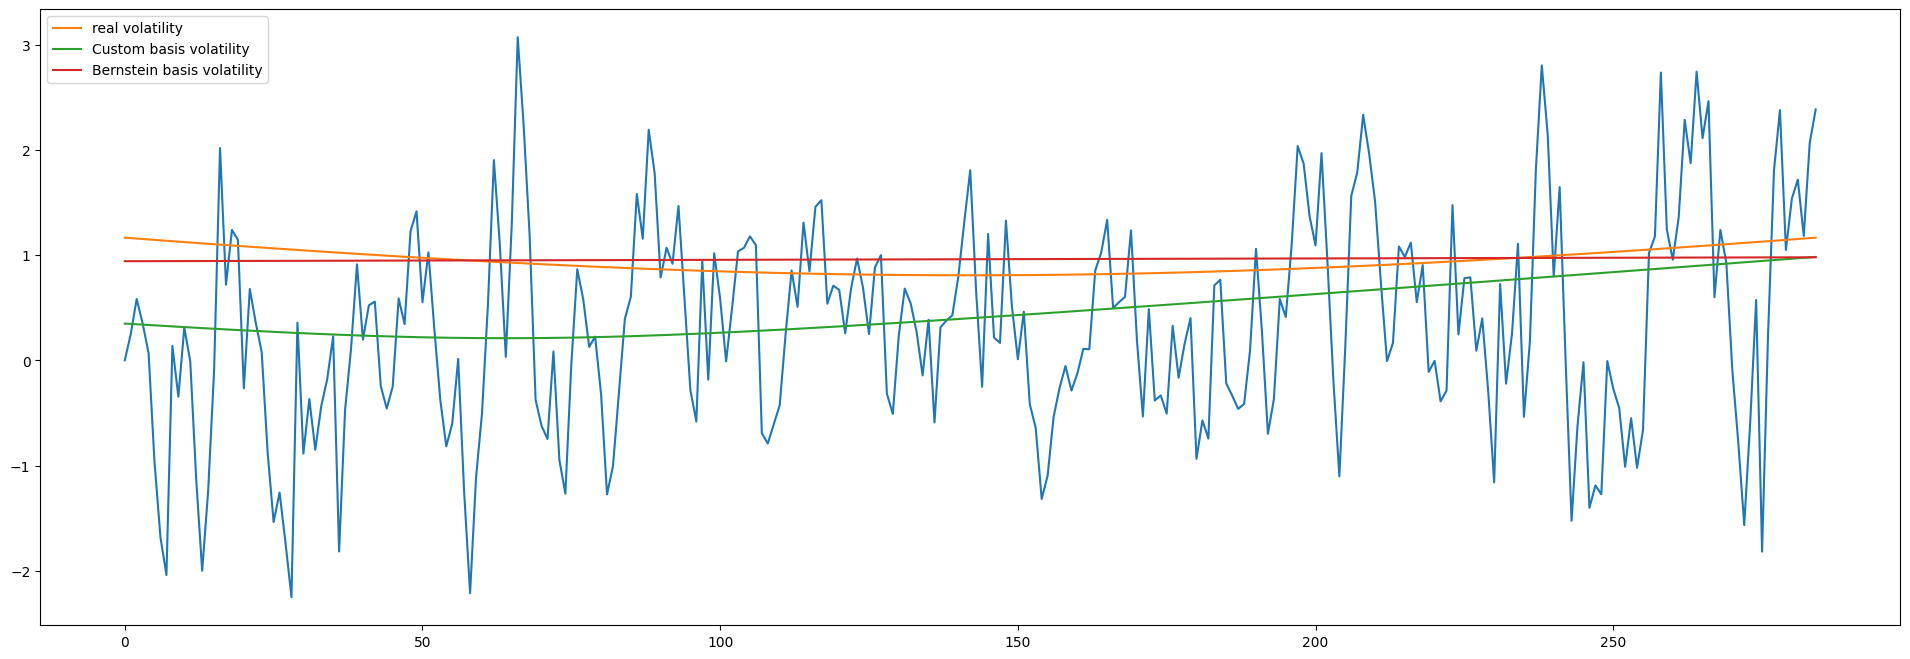

In [37]:
plt.plot(mY_example2[:, 100])
plt.plot(np.sqrt(mSigma_example2[:, 100]), label = 'real volatility')
plt.plot(np.sqrt(mSigma_hat_example2_db[:, 100]), label = 'Custom basis volatility')
plt.plot(np.sqrt(mSigma_hat_example2[:, 100]), label = 'Bernstein basis volatility')
plt.legend()

Now we check if the basis is able to capture extreme functions

In [38]:
M: int = 3
config: dict = {
        'x0'        :   [.5] * (M + 2 * (M ** 2)),
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead', # Sequential least squares programming,
    }

# This is the extreme case
QMLE_example_basis_extreme = est.main(mY_example1, grid_length = 285, M = M, sigma2Int=np.ones(285), **config)

In [ ]:
plt.plot(mY_example1[:, 100])
plt.plot(np.sqrt(mSigma_example1[:, 100]), label = 'real volatility')
plt.plot(np.sqrt(QMLE_example_basis_extreme[:, 100]), label = 'Est volatility')
plt.legend()